<a href="https://colab.research.google.com/github/ajayanandakumar-ux/HTMLActorpage/blob/main/Diamond_Price_Prediction_(1)_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diamond Price Prediction

The aim of this analysis is to predict the price of diamonds based on their characteristics. The dataset used for this analysis is the Diamonds dataset from Kaggle. The dataset contains 53940 observations and 10 variables. The variables are as follows:


|Column Name|Description|
|-----------|-----------|
|carat|Weight of the diamond|
|cut|Quality of the cut (Fair, Good, Very Good, Premium, Ideal)|
|color|Diamond colour, from J (worst) to D (best)|
|clarity|How clear the diamond is (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))|
|x|Length in mm|
|y|Width in mm|
|z|Depth in mm|
|depth|Total depth percentage = z / mean(x, y) = 2 * z / (x + y) (43--79)|
|table|Width of top of diamond relative to widest point (43--95)|
|price|Price in US dollars (326--18,823)|


In [1]:
#importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Loading the Diamonds dataset
df = sns.load_dataset('diamonds')

# Display the first 5 rows
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## Data Preprocessing

In [ ]:
df.shape

(50000, 10)

In [4]:
# Basic information about the dataset
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (53940, 10)

Column Names:
['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [5]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())

Missing Values:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

Number of Duplicate Rows:
146


In [6]:
# Remove duplicate rows
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)
print("Remaining duplicate rows:", df.duplicated().sum())

Dataset shape after removing duplicates: (53794, 10)
Remaining duplicate rows: 0


Price Statistics:
count    53794.000000
mean      3933.065082
std       3988.114460
min        326.000000
25%        951.000000
50%       2401.000000
75%       5326.750000
max      18823.000000
Name: price, dtype: float64


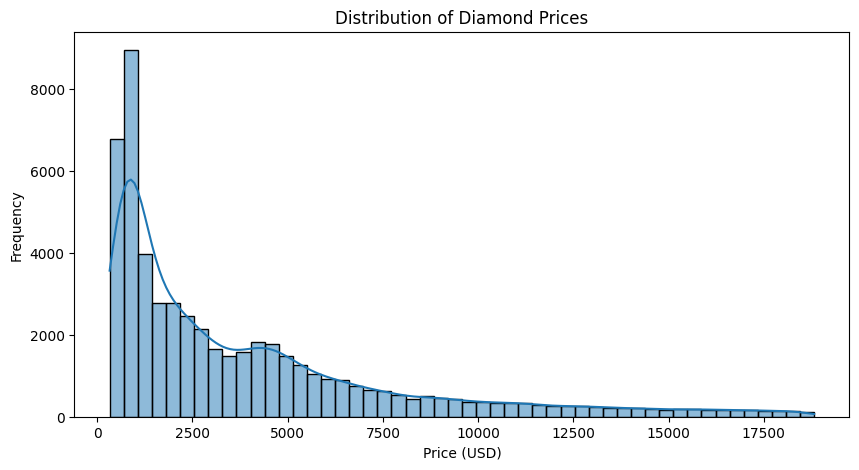

In [7]:
# Analyze the target variable
print("Price Statistics:")
print(df['price'].describe())

# Plot the price distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of Diamond Prices')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.show()

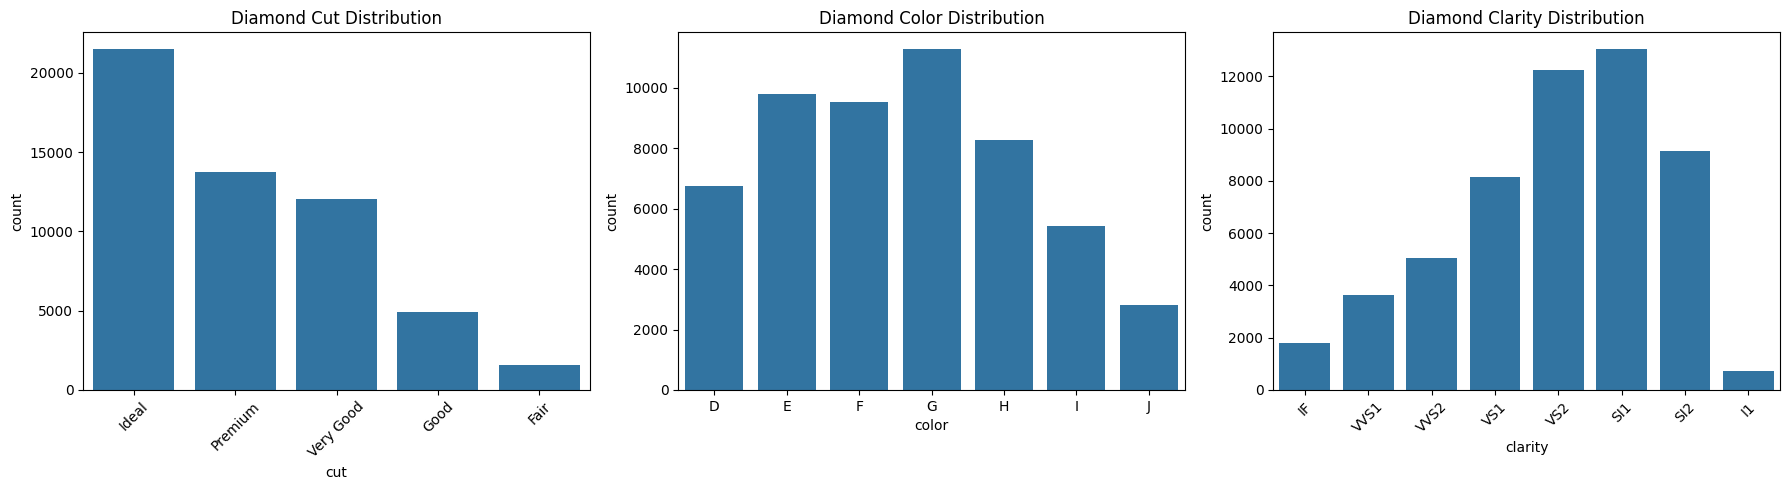

In [8]:
# Distribution of categorical features

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x='cut', ax=axes[0])
axes[0].set_title('Diamond Cut Distribution')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='color', ax=axes[1])
axes[1].set_title('Diamond Color Distribution')

sns.countplot(data=df, x='clarity', ax=axes[2])
axes[2].set_title('Diamond Clarity Distribution')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

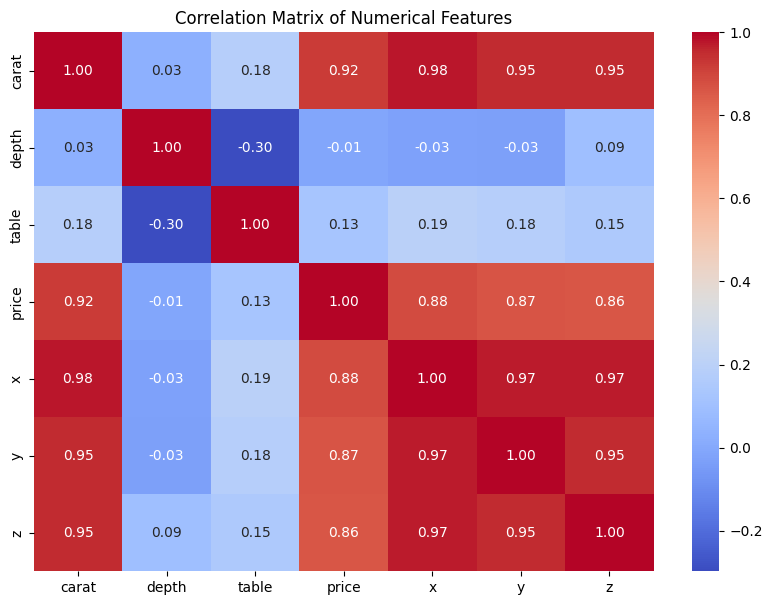

In [9]:
# Correlation analysis of numerical features

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 7))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Features')
plt.show()

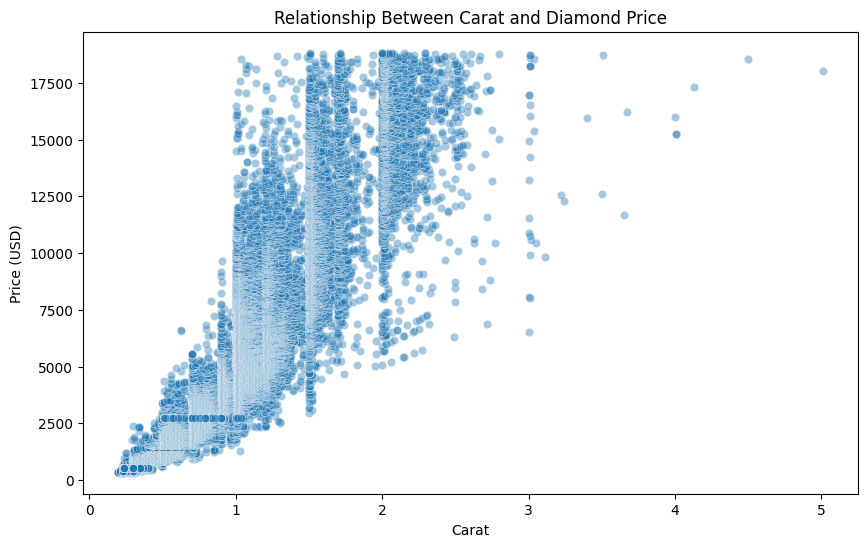

In [10]:
# Relationship between carat and price

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='carat',
    y='price',
    alpha=0.4
)

plt.title('Relationship Between Carat and Diamond Price')
plt.xlabel('Carat')
plt.ylabel('Price (USD)')
plt.show()

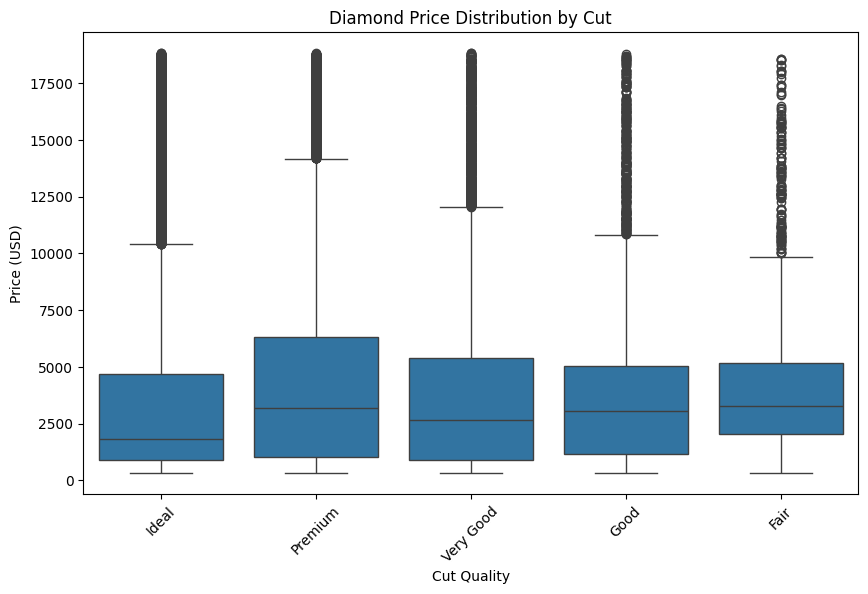

In [11]:
# Diamond price distribution by cut quality

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='cut',
    y='price'
)

plt.title('Diamond Price Distribution by Cut')
plt.xlabel('Cut Quality')
plt.ylabel('Price (USD)')
plt.xticks(rotation=45)
plt.show()

In [12]:
# Prepare data for Machine Learning

# Separate features and target
X = df.drop('price', axis=1)
y = df['price']

# Convert categorical variables into numerical variables
X = pd.get_dummies(
    X,
    columns=['cut', 'color', 'clarity'],
    drop_first=True
)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Display the first 5 rows
X.head()

Features shape: (53794, 23)
Target shape: (53794,)


,carat,depth,table,x,y,z,cut_Premium,cut_Very Good,cut_Good,cut_Fair,...,color_H,color_I,color_J,clarity_VVS1,clarity_VVS2,clarity_VS1,clarity_VS2,clarity_SI1,clarity_SI2,clarity_I1
0,0.23,61.5,55.0,3.95,3.98,2.43,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,0.21,59.8,61.0,3.89,3.84,2.31,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,0.23,56.9,65.0,4.05,4.07,2.31,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
3,0.29,62.4,58.0,4.20,4.23,2.63,True,False,False,False,...,False,True,False,False,False,False,True,False,False,False
4,0.31,63.3,58.0,4.34,4.35,2.75,False,False,True,False,...,False,False,True,False,False,False,False,False,True,False


In [13]:
# Split the data into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (43035, 23)
Testing data: (10759, 23)


In [14]:
# Train Linear Regression model

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create the model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

# Make predictions
y_pred_linear = linear_model.predict(X_test)

# Evaluate the model
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Performance")
print("--------------------------------")
print("MAE :", round(mae_linear, 2))
print("RMSE:", round(rmse_linear, 2))
print("R²  :", round(r2_linear, 4))

Linear Regression Performance
--------------------------------
MAE : 725.27
RMSE: 1102.31
R²  : 0.9203


In [15]:
# Train Random Forest Regression model

from sklearn.ensemble import RandomForestRegressor

# Create the model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-------------------------")
print("MAE :", round(mae_rf, 2))
print("RMSE:", round(rmse_rf, 2))
print("R²  :", round(r2_rf, 4))

Random Forest Performance
-------------------------
MAE : 270.73
RMSE: 530.99
R²  : 0.9815


In [16]:
# Train Gradient Boosting Regression model

from sklearn.ensemble import GradientBoostingRegressor

# Create the model
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

# Train the model
gb_model.fit(X_train, y_train)

# Make predictions
y_pred_gb = gb_model.predict(X_test)

# Evaluate the model
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Performance")
print("-----------------------------")
print("MAE :", round(mae_gb, 2))
print("RMSE:", round(rmse_gb, 2))
print("R²  :", round(r2_gb, 4))

Gradient Boosting Performance
-----------------------------
MAE : 325.09
RMSE: 627.34
R²  : 0.9742


In [17]:
# Compare all machine learning models

model_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'MAE': [
        mae_linear,
        mae_rf,
        mae_gb
    ],
    'RMSE': [
        rmse_linear,
        rmse_rf,
        rmse_gb
    ],
    'R2 Score': [
        r2_linear,
        r2_rf,
        r2_gb
    ]
})

model_results = model_results.sort_values(
    by='R2 Score',
    ascending=False
)

model_results

,Model,MAE,RMSE,R2 Score
1,Random Forest,270.730904,530.992515,0.981502
2,Gradient Boosting,325.088523,627.340610,0.974180
0,Linear Regression,725.270321,1102.312979,0.920280


In [18]:
# Feature importance of the Random Forest model

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("Top Features Influencing Diamond Price:")
display(feature_importance.head(10))

Top Features Influencing Diamond Price:


,Feature,Importance
0,carat,0.489587
4,y,0.396928
21,clarity_SI2,0.019571
22,clarity_I1,0.015308
20,clarity_SI1,0.014132
15,color_J,0.011103
14,color_I,0.008483
19,clarity_VS2,0.007279
13,color_H,0.006811
5,z,0.005759


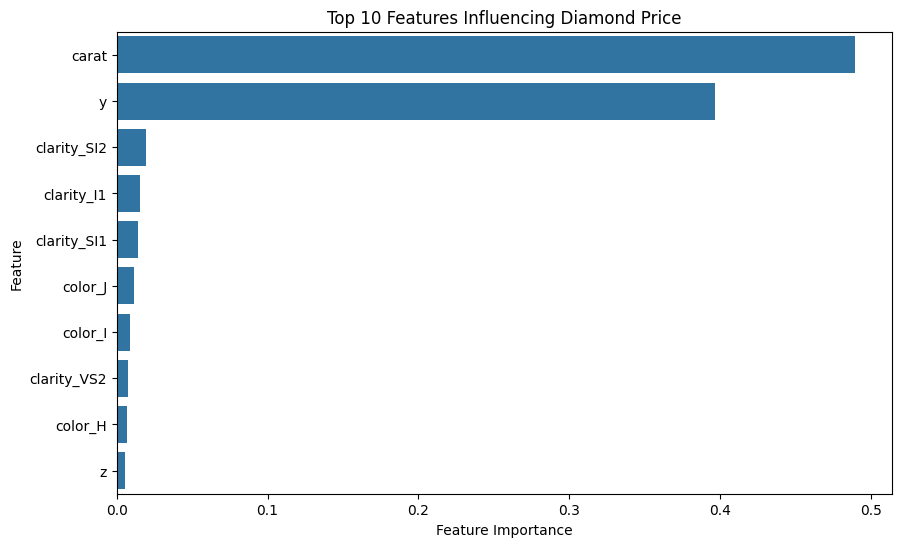

In [19]:
# Visualize top 10 important features

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Features Influencing Diamond Price')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')

plt.show()

In [20]:
# Predict diamond prices for sample test records

sample_data = X_test.head(10)

sample_predictions = rf_model.predict(sample_data)

prediction_results = pd.DataFrame({
    'Actual Price': y_test.head(10).values,
    'Predicted Price': sample_predictions
})

prediction_results['Difference'] = (
    prediction_results['Actual Price'] -
    prediction_results['Predicted Price']
)

prediction_results

,Actual Price,Predicted Price,Difference
0,1435,1681.03,-246.03
1,3584,3698.65,-114.65
2,1851,1875.14,-24.14
3,1590,1629.29,-39.29
4,5690,5336.98,353.02
5,596,624.61,-28.61
6,492,471.54,20.46
7,2063,2300.45,-237.45
8,970,1050.98,-80.98
9,4796,4782.16,13.84


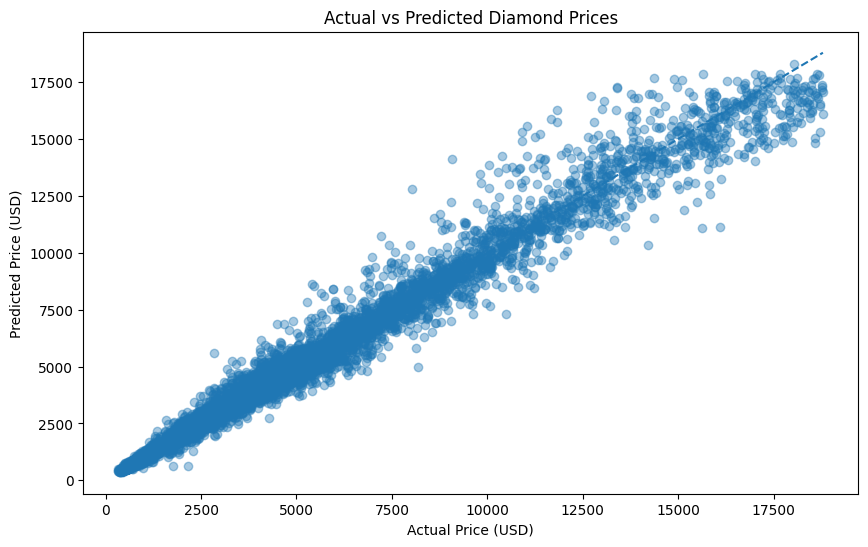

In [21]:
# Compare actual prices with predicted prices

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.4
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.title('Actual vs Predicted Diamond Prices')
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')

plt.show()

In [22]:
# Diamond Price Prediction Function

def predict_diamond_price(carat, cut, color, clarity, depth, table, x, y, z):

    # Create input data
    input_data = pd.DataFrame({
        'carat': [carat],
        'cut': [cut],
        'color': [color],
        'clarity': [clarity],
        'depth': [depth],
        'table': [table],
        'x': [x],
        'y': [y],
        'z': [z]
    })

    # Apply the same one-hot encoding used during training
    input_data = pd.get_dummies(
        input_data,
        columns=['cut', 'color', 'clarity'],
        drop_first=True
    )

    # Make sure input has exactly the same features as training data
    input_data = input_data.reindex(
        columns=X.columns,
        fill_value=0
    )

    # Predict price
    predicted_price = rf_model.predict(input_data)[0]

    return predicted_price

In [23]:
# Example diamond price prediction

predicted_price = predict_diamond_price(
    carat=1.2,
    cut='Premium',
    color='G',
    clarity='VS1',
    depth=61.0,
    table=57.0,
    x=6.8,
    y=6.9,
    z=4.2
)

print("Predicted Diamond Price: ${:,.2f}".format(predicted_price))

Predicted Diamond Price: $16,032.71


In [24]:
# Interactive Diamond Price Prediction System

import ipywidgets as widgets
from IPython.display import display, clear_output

# Create input fields
carat_input = widgets.FloatText(
    value=1.2,
    description='Carat:',
    step=0.1
)

cut_input = widgets.Dropdown(
    options=['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'],
    value='Premium',
    description='Cut:'
)

color_input = widgets.Dropdown(
    options=['D', 'E', 'F', 'G', 'H', 'I', 'J'],
    value='G',
    description='Color:'
)

clarity_input = widgets.Dropdown(
    options=['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF'],
    value='VS1',
    description='Clarity:'
)

depth_input = widgets.FloatText(
    value=61.0,
    description='Depth:',
    step=0.1
)

table_input = widgets.FloatText(
    value=57.0,
    description='Table:',
    step=0.1
)

x_input = widgets.FloatText(
    value=6.8,
    description='Length X:',
    step=0.1
)

y_input = widgets.FloatText(
    value=6.9,
    description='Width Y:',
    step=0.1
)

z_input = widgets.FloatText(
    value=4.2,
    description='Depth Z:',
    step=0.1
)

predict_button = widgets.Button(
    description='Predict Price',
    button_style='success'
)

output = widgets.Output()


def on_predict_clicked(b):
    with output:
        clear_output()

        predicted_price = predict_diamond_price(
            carat=carat_input.value,
            cut=cut_input.value,
            color=color_input.value,
            clarity=clarity_input.value,
            depth=depth_input.value,
            table=table_input.value,
            x=x_input.value,
            y=y_input.value,
            z=z_input.value
        )

        print("💎 Diamond Price Prediction")
        print("---------------------------")
        print(f"Estimated Price: ${predicted_price:,.2f}")


predict_button.on_click(on_predict_clicked)

display(
    carat_input,
    cut_input,
    color_input,
    clarity_input,
    depth_input,
    table_input,
    x_input,
    y_input,
    z_input,
    predict_button,
    output
)

FloatText(value=1.2, description='Carat:', step=0.1)

Dropdown(description='Cut:', index=3, options=('Fair', 'Good', 'Very Good', 'Premium', 'Ideal'), value='Premiu…

Dropdown(description='Color:', index=3, options=('D', 'E', 'F', 'G', 'H', 'I', 'J'), value='G')

Dropdown(description='Clarity:', index=4, options=('I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF'), va…

FloatText(value=61.0, description='Depth:', step=0.1)

...

FloatText(value=6.8, description='Length X:', step=0.1)

FloatText(value=6.9, description='Width Y:', step=0.1)

FloatText(value=4.2, description='Depth Z:', step=0.1)

Button(button_style='success', description='Predict Price', style=ButtonStyle())

Output()

In [25]:
import joblib

joblib.dump(rf_model, 'diamond_price_model.pkl')
joblib.dump(list(X.columns), 'diamond_features.pkl')

print("Model saved successfully!")

Model saved successfully!


In [ ]:
#checking for null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    50000 non-null  float64
 1   cut      50000 non-null  object 
 2   color    50000 non-null  object 
 3   clarity  50000 non-null  object 
 4   depth    50000 non-null  float64
 5   table    50000 non-null  float64
 6   price    50000 non-null  int64  
 7   x        50000 non-null  float64
 8   y        50000 non-null  float64
 9   z        50000 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 3.8+ MB


In [ ]:
#checking descriptive statistics
df.describe()

,carat,depth,table,price,x,y,z
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,0.799444,61.753006,57.457830,3944.805440,5.734403,5.737956,3.541056
std,0.475173,1.431088,2.232092,3997.938105,1.123077,1.145579,0.707065
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,951.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2410.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5351.000000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [ ]:
#values count of categorical variables
print(df.cut.value_counts(),'\n',df.color.value_counts(),'\n',df.clarity.value_counts())

cut
Ideal        19938
Premium      12806
Very Good    11204
Good          4557
Fair          1495
Name: count, dtype: int64 
 color
G    10452
E     9085
F     8864
H     7711
D     6224
I     5058
J     2606
Name: count, dtype: int64 
 clarity
SI1     12115
VS2     11404
SI2      8519
VS1      7579
VVS2     4694
VVS1     3369
IF       1632
I1        688
Name: count, dtype: int64


In [ ]:
df.head(10)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
5,0.24,Very Good,J,VVS2,62.8,57.0,336,3.94,3.96,2.48
6,0.24,Very Good,I,VVS1,62.3,57.0,336,3.95,3.98,2.47
7,0.26,Very Good,H,SI1,61.9,55.0,337,4.07,4.11,2.53
8,0.22,Fair,E,VS2,65.1,61.0,337,3.87,3.78,2.49
9,0.23,Very Good,H,VS1,59.4,61.0,338,4.00,4.05,2.39


## Exploratory Data Analysis

<Axes: xlabel='price', ylabel='Count'>

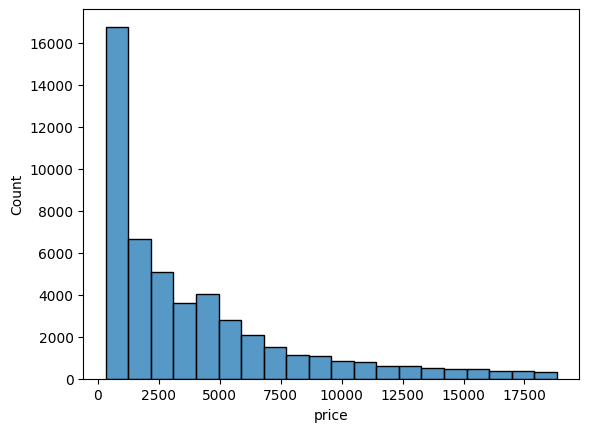

In [ ]:
sns.histplot(df['price'],bins = 20)

<Axes: xlabel='carat', ylabel='Count'>

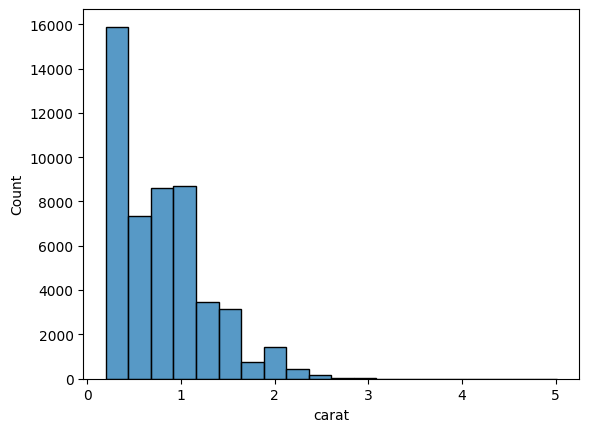

In [ ]:
sns.histplot(df['carat'],bins=20)

Most of the diamonds are less then 1 carat in weight.

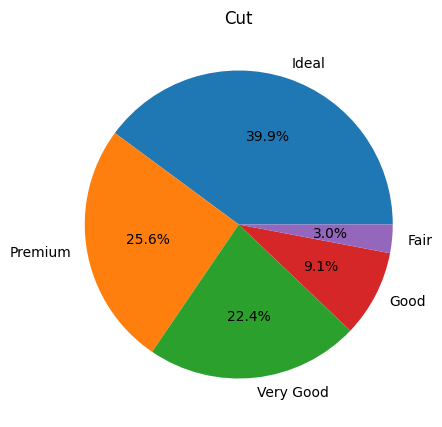

In [ ]:
plt.figure(figsize=(5,5))
plt.pie(df['cut'].value_counts(),labels=['Ideal','Premium','Very Good','Good','Fair'],autopct='%1.1f%%')
plt.title('Cut')
plt.show()

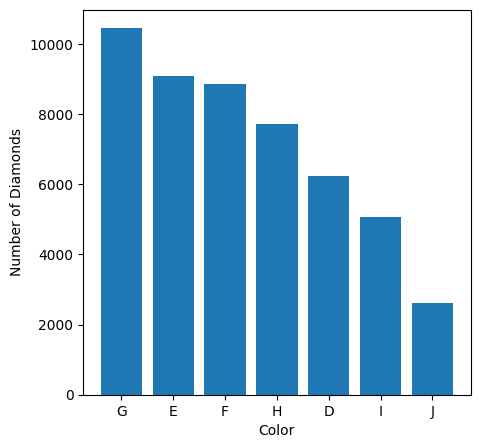

In [ ]:
plt.figure(figsize=(5,5))
plt.bar(df['color'].value_counts().index,df['color'].value_counts())
plt.ylabel("Number of Diamonds")
plt.xlabel("Color")
plt.show()

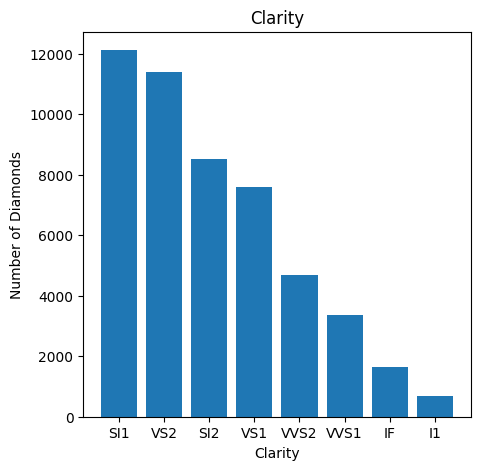

In [ ]:
plt.figure(figsize=(5,5))
plt.bar(df['clarity'].value_counts().index,df['clarity'].value_counts())
plt.title('Clarity')
plt.ylabel("Number of Diamonds")
plt.xlabel("Clarity")
plt.show()

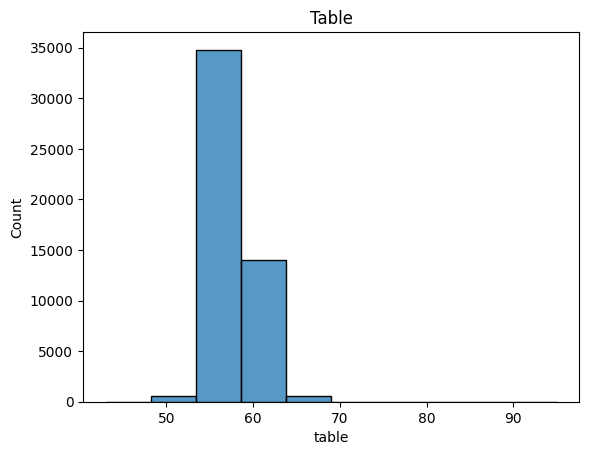

In [ ]:
sns.histplot(df['table'],bins=10)
plt.title('Table')
plt.show()

### Comparing Diamond's features with Price

<Axes: xlabel='cut', ylabel='price'>

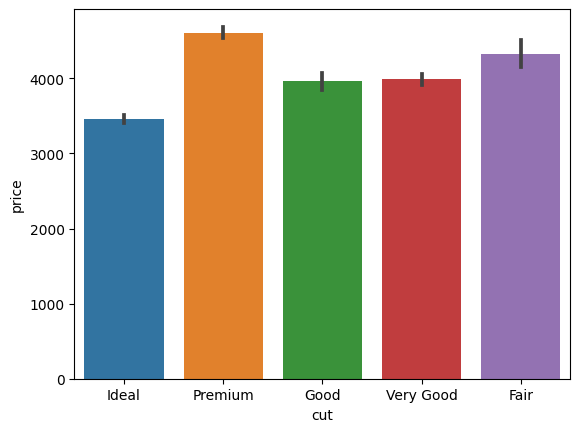

In [ ]:
sns.barplot(x='cut',y='price',data=df)

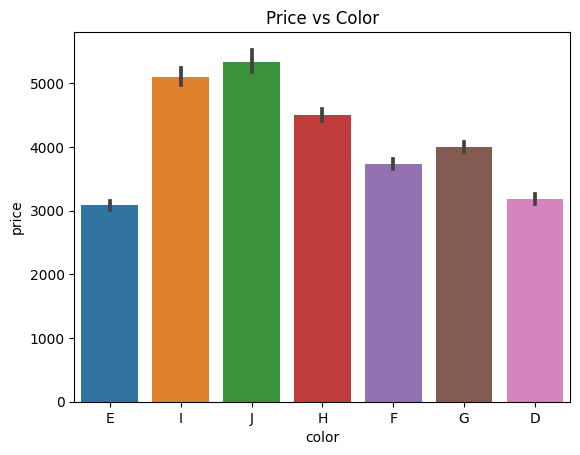

In [ ]:
sns.barplot(x='color',y='price',data=df)
plt.title('Price vs Color')
plt.show()

<Axes: xlabel='clarity', ylabel='price'>

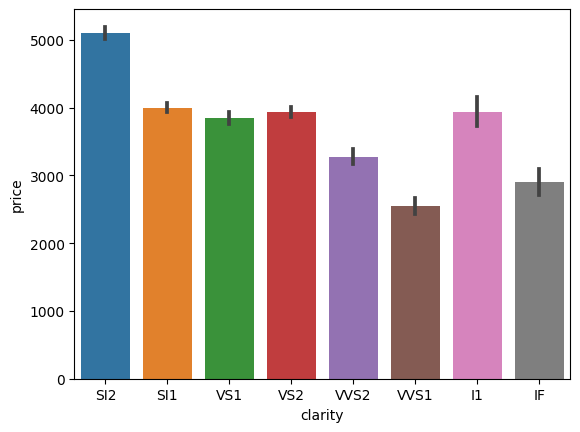

In [ ]:
sns.barplot(x = 'clarity', y = 'price', data = df)

J color and I1 clarity are worst featiures for a diamond, however when the data is plotted on bar graph, it is seen that the price of diamonds with J color and I1 clarity is higher than the price of diamonds with D color and IF clarity, which is opposite to what I expected.

## Data Preprocessing 2

In [ ]:
#changing categorical variables to numerical variables
df['cut'] = df['cut'].map({'Ideal':5,'Premium':4,'Very Good':3,'Good':2,'Fair':1})
df['color'] = df['color'].map({'D':7,'E':6,'F':5,'G':4,'H':3,'I':2,'J':1})
df['clarity'] = df['clarity'].map({'IF':8,'VVS1':7,'VVS2':6,'VS1':5,'VS2':4,'SI1':3,'SI2':2,'I1':1})

## Coorelation

In [ ]:
#coorelation matrix
df.corr()

,carat,cut,color,clarity,depth,table,price,x,y,z
carat,1.000000,-0.135135,-0.291530,-0.352435,0.027734,0.183639,0.921804,0.975037,0.950035,0.952700
cut,-0.135135,1.000000,0.019548,0.189024,-0.223898,-0.432154,-0.053537,-0.125738,-0.121335,-0.149830
color,-0.291530,0.019548,1.000000,-0.026056,-0.047426,-0.027513,-0.172629,-0.270529,-0.263395,-0.268388
clarity,-0.352435,0.189024,-0.026056,1.000000,-0.067329,-0.159967,-0.146941,-0.371355,-0.357226,-0.366218
depth,0.027734,-0.223898,-0.047426,-0.067329,1.000000,-0.293012,-0.012731,-0.025563,-0.029809,0.094337
table,0.183639,-0.432154,-0.027513,-0.159967,-0.293012,1.000000,0.129848,0.197198,0.185248,0.153161
price,0.921804,-0.053537,-0.172629,-0.146941,-0.012731,0.129848,1.000000,0.884919,0.864393,0.860963
x,0.975037,-0.125738,-0.270529,-0.371355,-0.025563,0.197198,0.884919,1.000000,0.972977,0.970122
y,0.950035,-0.121335,-0.263395,-0.357226,-0.029809,0.185248,0.864393,0.972977,1.000000,0.950030
z,0.952700,-0.149830,-0.268388,-0.366218,0.094337,0.153161,0.860963,0.970122,0.950030,1.000000


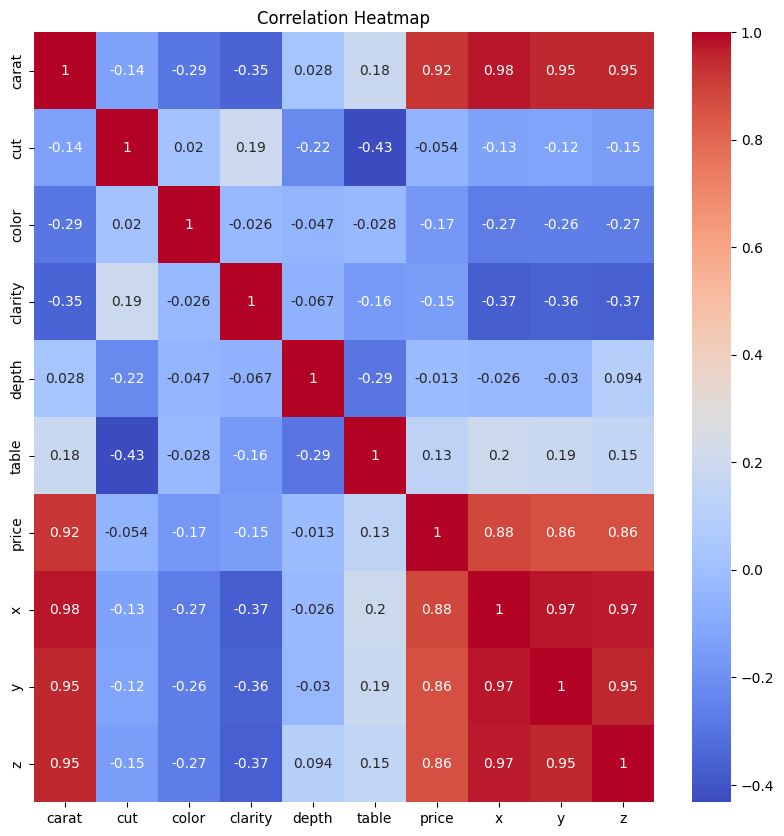

In [ ]:
#plotting the correlation heatmap
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

#### Ploting the relationship between Price and Carat

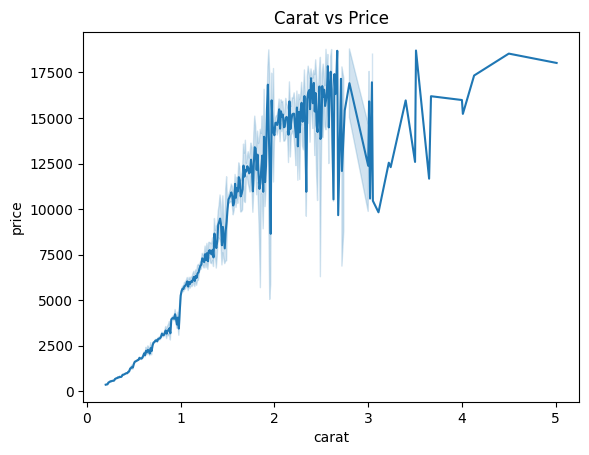

In [ ]:
sns.lineplot(x='carat',y='price',data=df)
plt.title('Carat vs Price')
plt.show()

From the lineplot it is quite clear that the price of the diamond increases with the increase in the carat of the diamond. However, diamonds with less carat also have high price. This is because of the other factors that affect the price of the diamond.

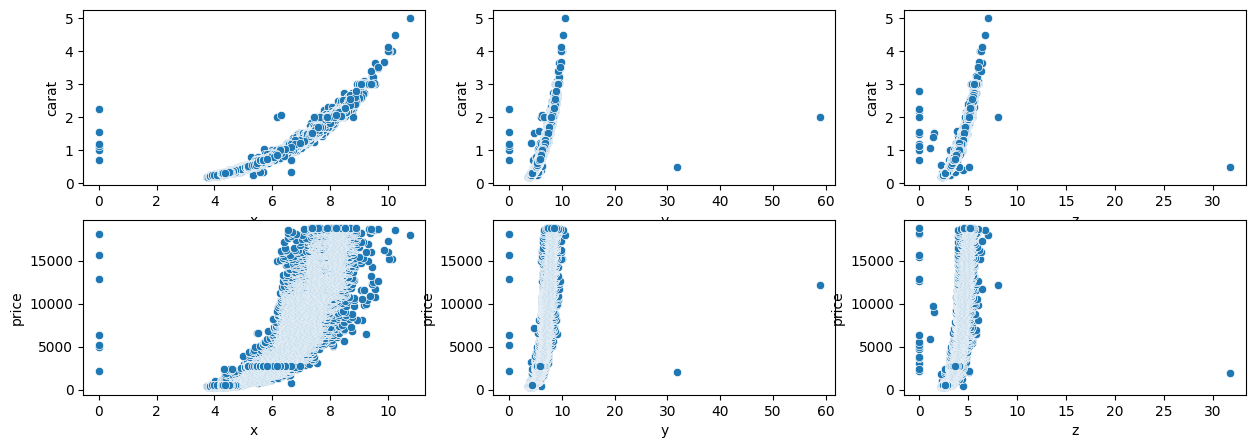

In [ ]:
fig, ax = plt.subplots(2,3,figsize=(15,5))
sns.scatterplot(x='x',y='carat',data=df, ax=ax[0,0])
sns.scatterplot(x='y',y='carat',data=df, ax=ax[0,1])
sns.scatterplot(x='z',y='carat',data=df, ax=ax[0,2])
sns.scatterplot(x='x',y='price',data=df, ax=ax[1,0])
sns.scatterplot(x='y',y='price',data=df, ax=ax[1,1])
sns.scatterplot(x='z',y='price',data=df, ax=ax[1,2])
plt.show()

Majority of the diamonds have x values between 4 and 8, y values between 4 and 10 and z values between 2 and 6. Diamonds with other dimensions are very rare.

## Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split
x_test,x_train,y_test,y_train = train_test_split(df.drop('price',axis=1),df['price'],test_size=0.2,random_state=42)

## Model Building

### Decision Tree Regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
dt

DecisionTreeRegressor()

In [ ]:
#training the model
dt.fit(x_train,y_train)
#train accuracy
dt.score(x_train,y_train)

0.9999995617234543

In [ ]:
#predicting the test set
dt_pred = dt.predict(x_test)

### Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
rf

RandomForestRegressor()

In [ ]:
#training the model
rf.fit(x_train,y_train)
#train accuracy
rf.score(x_train,y_train)

0.99711333722628

In [ ]:
#predicting the test set
rf_pred = rf.predict(x_test)

## Model Evaluation

In [ ]:
from sklearn.metrics import mean_squared_error,mean_absolute_error

### Decision Tree Regressor

C:\Users\DELL\AppData\Local\Temp\ipykernel_13152\3672894792.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(y_test,hist=False,color='r',label='Actual Value')
C:\Users\DELL\AppData\Local\Temp\ipykernel_13152\3672894792.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot

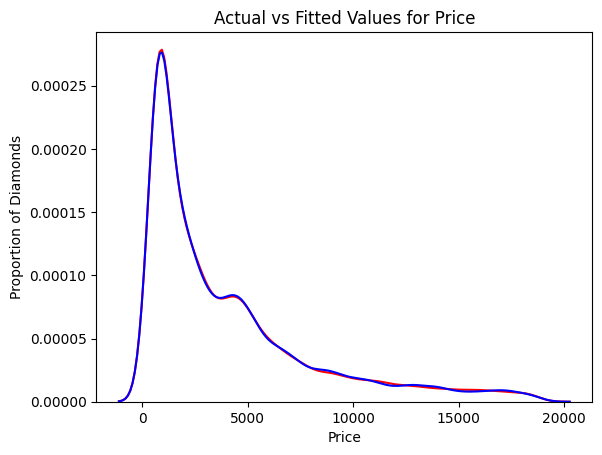

In [ ]:
#distribution plot for actual and predicted values
ax = sns.distplot(y_test,hist=False,color='r',label='Actual Value')
sns.distplot(dt_pred,hist=False,color='b',label='Fitted Values',ax=ax)
plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price')
plt.ylabel('Proportion of Diamonds')
plt.show()

In [ ]:
print('Decision Tree Regressor RMSE:',np.sqrt(mean_squared_error(y_test,dt_pred)))
print('Decision Tree Regressor Accuracy:',dt.score(x_test,y_test))
print('Decision Tree Regressor MAE:',mean_absolute_error(y_test,dt_pred))

Decision Tree Regressor RMSE: 803.7869467013631
Decision Tree Regressor Accuracy: 0.9599057693807272
Decision Tree Regressor MAE: 408.96015


### Random Forest Regressor

C:\Users\DELL\AppData\Local\Temp\ipykernel_13152\4187378959.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(y_test,hist=False,color='r',label='Actual Value')
C:\Users\DELL\AppData\Local\Temp\ipykernel_13152\4187378959.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot

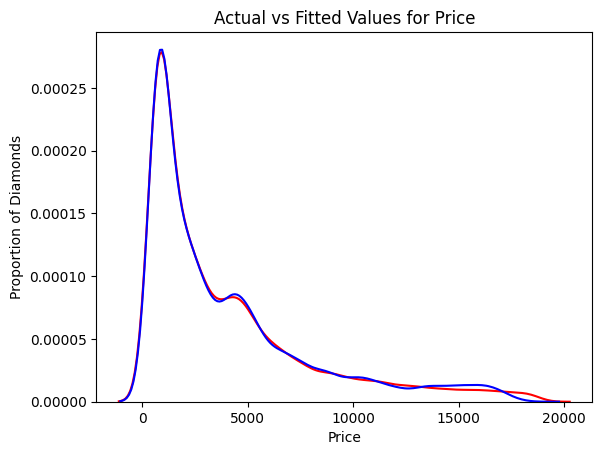

In [ ]:
#distribution plot for actual and predicted values
ax = sns.distplot(y_test,hist=False,color='r',label='Actual Value')
sns.distplot(rf_pred,hist=False,color='b',label='Fitted Values',ax=ax)
plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price')
plt.ylabel('Proportion of Diamonds')
plt.show()

In [ ]:
print('Random Forest Regressor RMSE:',np.sqrt(mean_squared_error(y_test,rf_pred)))
print('Random Forest Regressor Accuracy:',rf.score(x_test,y_test))
print('Random Forest Regressor MAE:',mean_absolute_error(y_test,rf_pred))

Random Forest Regressor RMSE: 620.3188867364595
Random Forest Regressor Accuracy: 0.9761202379789445
Random Forest Regressor MAE: 306.1187898892857


## Conclusion

Both the models have almost same accuracy. However, the Random Forest Regressor model is slightly better than the Decision Tree Regressor model.

There is something interesting about the data. The price of the diamonds with J color and I1 clarity is higher than the price of the diamonds with D color and IF clarity which couldn't be explained by the models. This could be because of the other factors that affect the price of the diamond.

